# Setting Up


Cross-registration allows the user to register the outcomes of the MiniAn pipeline across multiple experimental sessions.
It is a useful add-on to deal with longitudinal experiments.


## specify directories and dataset patterns


For cross-registration to work, we need to have existing datasets with proper metadata.
At the minimum, a dimension `session` should exists on all the datasets.
Each dataset can either be a directory of `zarr` arrays (the default output format of `save_minian`), or a single file saved by users.
Each dataset should reside in its own directory.

Details on the parameters:

- `dpath` is the path containing all the datasets.
  It will be traversed recursively to search for datasets.
- `f_pattern` is the directory/file name pattern of each dataset.
  The program will attempt to load all directories/files matching `f_pattern` under `dpath`.
  Note that here our demo data are `netcdf` files that are manually saved.
  For the default minian dataset format (directory of `zarr` arrays), `f_pattern = r"minian$"` should suffice.
- `id_dims` is the name of dimensions that can uniquely identify each dataset.
  It should at least contain a `"session"` dimension.


In [11]:
dpath = "../demo_data/"
f_pattern = r"minian.nc$"
id_dims = ["session"]

## specify parameters


`param_dist` defines the maximal distance between cell centroids (in pixel units) on different sessions to consider them as the same cell.
`output_size` controls the scale of visualizations.


In [20]:
param_dist = 5
output_size = 100

cmap2use = "Viridis"
frame_width2use = 500

## load modules


In [13]:
%%capture
%load_ext autoreload
%autoreload 2
import os
import xarray as xr
import holoviews as hv
from dask.diagnostics import ProgressBar
from minian.cross_registration import (
    calculate_centroids,
    calculate_centroid_distance,
    calculate_mapping,
    group_by_session,
    resolve_mapping,
    fill_mapping,
)
from minian.motion_correction import estimate_motion, apply_transform
from minian.utilities import open_minian, open_minian_mf
from minian.visualization import AlignViewer

## module initialization


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
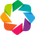

In [14]:
hv.notebook_extension("bokeh", width=100)
pbar = ProgressBar(minimum=2)
pbar.register()

# Allign Videos


## open datasets


All the metadata defined in `id_dims` will be printed out for each dataset.
It is important to make sure all the metadata are correct, otherwise you may get unexpected results.
If metadata was not saved correctly, consider putting the datasets into correct hierarchical directory structures and use the `post_process` argument of `open_minian_mf` to correct for metadata.
See the main `pipeline.ipynb` and [API reference](https://minian.readthedocs.io/page/api/minian.utilities.html#minian-utilities-open_minian_mf) for more detail.


In [15]:
minian_ds = open_minian_mf(dpath, id_dims, pattern=f_pattern)

## estimate shifts


Here we estimate a translational shift along the `session` dimension using the max projection for each dataset.
We combine the `shifts`, original templates `temps`, and shifted templates `temps_sh` into a single dataset `shiftds` to use later.


In [16]:
%%time
temps = minian_ds["max_proj"].rename("temps")
shifts = estimate_motion(temps, dim="session").compute().rename("shifts")
temps_sh = apply_transform(temps, shifts).compute().rename("temps_shifted")
shiftds = xr.merge([temps, shifts, temps_sh])

CPU times: user 96.7 ms, sys: 31.6 ms, total: 128 ms
Wall time: 537 ms


## visualize alignment


We visualize alignment of sessions by plotting the templates before and after the shift for each session.


In [21]:
hv.output(size=int(output_size * 0.6))
opts_im = {
    "aspect": shiftds.sizes["width"] / shiftds.sizes["height"],
    "frame_width": frame_width2use,
    "cmap": cmap2use,
}
hv_temps = (
    hv.Dataset(temps)
    .to(hv.Image, kdims=["width", "height"])
    .opts(**opts_im)
    .layout("session")
    .cols(1)
)
hv_temps_sh = (
    hv.Dataset(temps_sh)
    .to(hv.Image, kdims=["width", "height"])
    .opts(**opts_im)
    .layout("session")
    .cols(1)
)
display(hv_temps + hv_temps_sh)

:Layout
   .NdLayout.I  :NdLayout   [session]
      :Image   [width,height]   (temps)
   .NdLayout.II :NdLayout   [session]
      :Image   [width,height]   (temps_shifted)

## visualize overlap of field of view across all sessions


Since only pixels that are common across all sessions are considered, it is important to sanity-check that this overlap window capture most of our cells.


In [22]:
hv.output(size=int(output_size * 0.6))
opts_im = {
    "aspect": shiftds.sizes["width"] / shiftds.sizes["height"],
    "frame_width": frame_width2use,
    "cmap": cmap2use,
}
window = shiftds["temps_shifted"].isnull().sum("session")
window, _ = xr.broadcast(window, shiftds["temps_shifted"])
hv_wnd = hv.Dataset(window).to(hv.Image, ["width", "height"])
hv_temps = hv.Dataset(temps_sh).to(hv.Image, ["width", "height"])
hv_wnd.opts(**opts_im).relabel("Window") + hv_temps.opts(**opts_im).relabel(
    "Shifted Templates"
)

:Layout
   .HoloMap.Window            :HoloMap   [session]
      :Image   [width,height]   (temps_shifted)
   .HoloMap.Shifted_Templates :HoloMap   [session]
      :Image   [width,height]   (temps_shifted)

## apply shifts and set window


If the shifts and overlaps all look good, we commit by applying them to the spatial footprints of each session.


In [23]:
A_shifted = apply_transform(
    minian_ds["A"].chunk(dict(height=-1, width=-1)), shiftds["shifts"]
)

In [24]:
def set_window(wnd):
    return wnd == wnd.min()


window = xr.apply_ufunc(
    set_window,
    window,
    input_core_dims=[["height", "width"]],
    output_core_dims=[["height", "width"]],
    vectorize=True,
)

# Cross-session registration


## calculate centroids


We start by calculating a centroid of spatial footprint for each cell.
The centroid location is the only source of information used to register cells across sessions.


In [25]:
%%time
cents = calculate_centroids(A_shifted, window)

[########################################] | 100% Completed | 3.17 s
[########################################] | 100% Completed | 3.27 s
[########################################] | 100% Completed | 3.37 s
CPU times: user 3.67 s, sys: 1.56 s, total: 5.24 s
Wall time: 3.4 s


## calculate centroid distance


We then calculate pairwise distance between cells in all pairs of sessions.
Note that at this stage, since we are computing something along the `session` dimension, it is no longer considered as a metadata dimension, so we remove it.


In [26]:
%%time
id_dims.remove("session")
dist = calculate_centroid_distance(cents, index_dim=id_dims)

CPU times: user 146 ms, sys: 14.3 ms, total: 161 ms
Wall time: 357 ms


## threshold centroid distances


We threshold the centroid distances and keep only cell pairs with distance less than `param_dist`.


In [27]:
dist_ft = dist[dist["variable", "distance"] < param_dist].copy()
dist_ft = group_by_session(dist_ft)

## generate mappings


Finally we generate mapping of cells across session in three steps:

1. We filter the pairwise distances into pairwise mappings by applying a mutual nearest-neighbour criteria, using `calculate_mapping`.
1. We extend/merge pairwise mappings into multi-session mappings and drop any conficting mappings, using `resolve_mapping`.
1. We fill in "mappings" that represent cells only appeared in single sessions, using `fill_mapping`.

Please see the [API reference](https://minian.readthedocs.io/page/api/minian.cross_registration.html) for more detail on the output dataframe format.


In [28]:
%%time
mappings = calculate_mapping(dist_ft)
mappings_meta = resolve_mapping(mappings)
mappings_meta_fill = fill_mapping(mappings_meta, cents)
mappings_meta_fill.head()

CPU times: user 120 ms, sys: 5.47 ms, total: 126 ms
Wall time: 123 ms


session          variable                 group
  session1 session2 distance                 group
0     72.0     89.0      NaN  (session1, session2)
1    129.0    135.0      NaN  (session1, session2)
2    100.0    108.0      NaN  (session1, session2)
3    151.0    153.0      NaN  (session1, session2)
4     57.0     64.0      NaN  (session1, session2)

## visualize mappings


We visualize the matching of cells by color-mapping cells 3 arbitrary sessions into RGB channels and plot the overlay image.
Please see [API reference](https://minian.readthedocs.io/page/api/minian.visualization.html#minian-visualization-AlignViewer) for more details on the tools available in this visualization.


In [29]:
hv.output(size=int(output_size * 0.7))
alnviewer = AlignViewer(minian_ds, cents, mappings_meta_fill, shiftds)
alnviewer.show()

[########################################] | 100% Completed | 2.96 s
[########################################] | 100% Completed | 3.07 s
[########################################] | 100% Completed | 3.17 s


Row
    [0] HoloViews(RGB, sizing_mode='fixed')
    [1] Column
        [0] WidgetBox
            [0] Select(name='sessionR', options=['session1', 'session2'], value='session1')
            [1] Select(name='sessionG', options=['session1', 'session2'], value='session1')
            [2] Select(name='sessionB', options=['session1', 'session2'], value='session1')
        [1] WidgetBox
            [0] Select(name='erode', options=[0, 1, 2, 3, 4, ...], value=3)
            [1] Checkbox(name='show matched', value=True)
            [2] Checkbox(name='show unmatched', value=True)

## save results


If everything looks good, we commit by saving the mappings into `pickle` file.
Optionally we also save centroids `cents` and `shiftds` in case they come in handy in down-stream analysis.


In [30]:
mappings_meta_fill.to_pickle(os.path.join(dpath, "mappings.pkl"))
cents.to_pickle(os.path.join(dpath, "cents.pkl"))
shiftds.to_netcdf(os.path.join(dpath, "shiftds.nc"))

## For long term storage, can save the mappings and centroids as netcdf files
## Not recommended to use pickle long term due to version stability issues and security concerns
# mappings_meta_fill.to_netcdf(os.path.join(dpath, "mappings.nc"))
# cents.to_netcdf(os.path.join(dpath, "cents.nc"))